# **Implementación de Modelos Predictivo**

## **1.Importación de Librerias** 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
df = pd.read_csv('avocado_clean.csv')

Límite inferior: 0.26
Límite superior: 2.50
Cantidad de outliers: 209


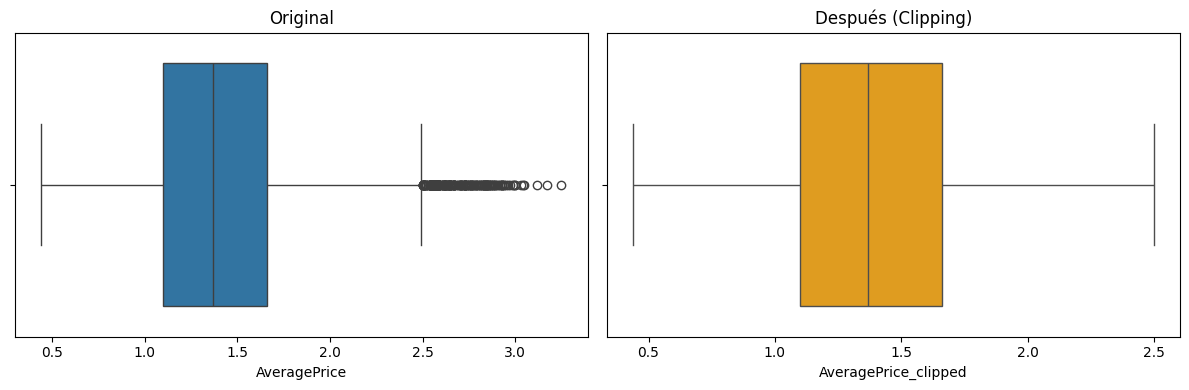

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Q1 = df['AveragePrice'].quantile(0.25)
Q3 = df['AveragePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")

outliers = df[(df['AveragePrice'] < lower_bound) |
              (df['AveragePrice'] > upper_bound)]

print(f"Cantidad de outliers: {len(outliers)}")

df['AveragePrice_clipped'] = np.clip(
    df['AveragePrice'], lower_bound, upper_bound
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['AveragePrice'], ax=axes[0])
axes[0].set_title('Original')

sns.boxplot(x=df['AveragePrice_clipped'], ax=axes[1], color='orange')
axes[1].set_title('Después (Clipping)')

plt.tight_layout()
plt.show()

## **2. Regresión Lineal**

In [4]:
X = df.drop(columns=['AveragePrice', 'AveragePrice_clipped'])
y = df['AveragePrice_clipped']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred_lr = modelo.predict(X_test)
print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_lr)}")
print(f"R²: {r2_score(y_test, y_pred_lr)}")

Error Cuadrático Medio: 0.07152821608468792
R²: 0.5418618093019216


## **3. Ramdom Forest**


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_rf)}")
print(f"R²: {r2_score(y_test, y_pred_rf)}")


Error Cuadrático Medio: 0.025656361837671227
R²: 0.8356710143827824


## **4. Redes Neuronales**

In [6]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(500,250), max_iter=100, early_stopping=False, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_mlp)}")
print(f"R²: {r2_score(y_test, y_pred_mlp)}")

Error Cuadrático Medio: 0.04383963253253917
R²: 0.7192071740535741


C:\Users\LENOVO-PC\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


## **#. Tabla Comparativa 1 Regresión**

In [9]:
tabla_resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'Red Neuronal'],
    'Error Cuadrático Medio': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_mlp)
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_mlp)
    ]
})

tabla_resultados

,Modelo,Error Cuadrático Medio,R²
0,Regresión Lineal,0.071528,0.541862
1,Random Forest,0.025656,0.835671
2,Red Neuronal,0.043840,0.719207


## Grafica de comparación 1

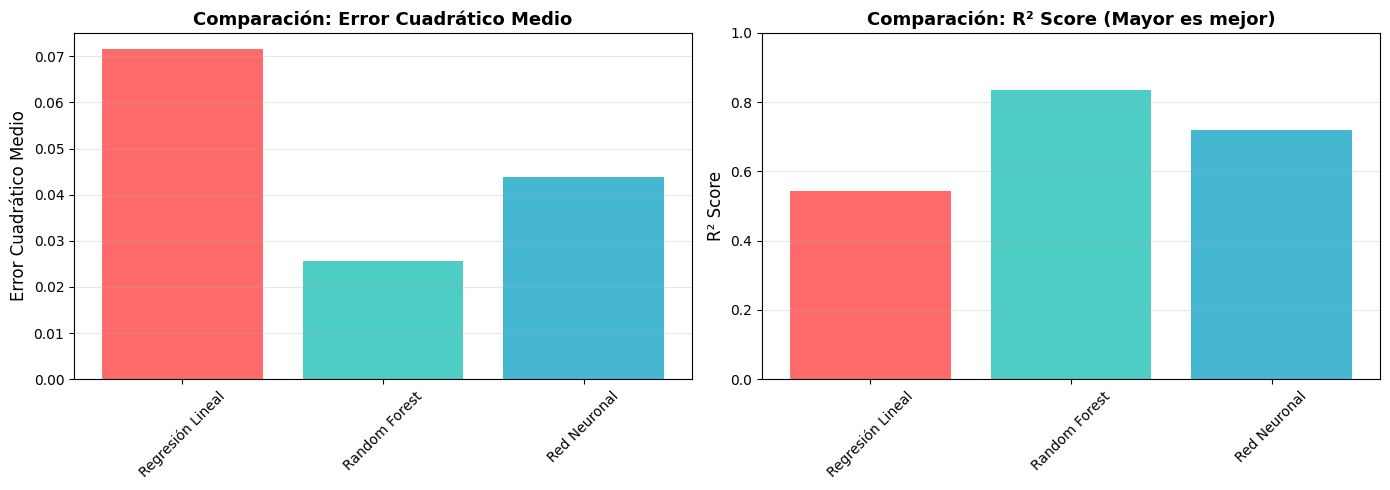

In [10]:
# Gráfica comparativa de modelos de regresión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Error Cuadrático Medio
axes[0].bar(tabla_resultados['Modelo'], tabla_resultados['Error Cuadrático Medio'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_ylabel('Error Cuadrático Medio', fontsize=12)
axes[0].set_title('Comparación: Error Cuadrático Medio', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfica 2: R² Score
axes[1].bar(tabla_resultados['Modelo'], tabla_resultados['R²'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Comparación: R² Score (Mayor es mejor)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




# Importar librerias

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree


from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay,
                             mean_squared_error, r2_score)

# Cargar dataset

In [12]:
df = pd.read_csv('avocado_clean.csv')
df.head()

,AveragePrice,4046,4225,4770,Small Bags,Large Bags,XLarge Bags,type_organic,region_Atlanta,region_BaltimoreWashington,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,1.33,-0.230816,-0.199902,-0.212090,-0.232647,-0.222351,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.35,-0.231102,-0.208055,-0.211997,-0.231568,-0.222335,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.93,-0.231007,-0.154478,-0.211327,-0.233399,-0.222310,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.08,-0.230740,-0.185350,-0.211866,-0.236568,-0.222187,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.28,-0.230891,-0.208719,-0.211839,-0.236154,-0.221925,-0.175572,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Crear variable objeto discreta

In [13]:
df['price_class'] = pd.qcut(df['AveragePrice'], q=3, labels=['Bajo','Medio','Alto'])
df['price_class'].value_counts()

price_class
Medio    6178
Bajo     6115
Alto     5956
Name: count, dtype: int64

# Separar variables, se quitan AveragePrice y price_class

In [14]:
X = df.drop(columns=['AveragePrice','price_class'])
y = df['price_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(14599, 60) (3650, 60)


# Escalado (necesario para KNN)
## 80% 20%


In [15]:


scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Implementación del modelo: K-Nearest Neighbors (KNN).

In [16]:
params_knn = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
pred_knn = best_knn.predict(X_test_scaled)

print('Mejores parámetros:', grid_knn.best_params_)
print('Accuracy:', accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

Mejores parámetros: {'n_neighbors': 7, 'weights': 'distance'}
Accuracy: 0.7868493150684932
              precision    recall  f1-score   support

        Alto       0.81      0.84      0.82      1191
        Bajo       0.86      0.83      0.84      1223
       Medio       0.70      0.70      0.70      1236

    accuracy                           0.79      3650
   macro avg       0.79      0.79      0.79      3650
weighted avg       0.79      0.79      0.79      3650



## Matriz de confusión

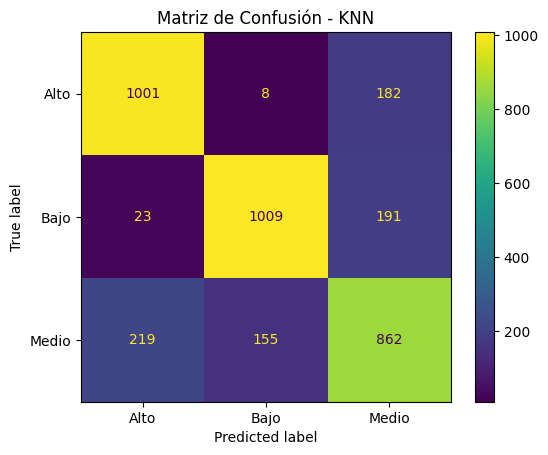

In [17]:
cm = confusion_matrix(y_test, pred_knn, labels=best_knn.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=best_knn.classes_)
disp.plot()
plt.title('Matriz de Confusión - KNN')
plt.show()

# Implementacion modelo: Árbol de decisión

In [18]:
params_tree = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), params_tree, cv=5, scoring='accuracy', n_jobs=-1)
grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_
pred_tree = best_tree.predict(X_test)

print('Mejores parámetros:', grid_tree.best_params_)
print('Accuracy:', accuracy_score(y_test, pred_tree))
print(classification_report(y_test, pred_tree))

Mejores parámetros: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
Accuracy: 0.736986301369863
              precision    recall  f1-score   support

        Alto       0.76      0.78      0.77      1191
        Bajo       0.80      0.80      0.80      1223
       Medio       0.64      0.64      0.64      1236

    accuracy                           0.74      3650
   macro avg       0.74      0.74      0.74      3650
weighted avg       0.74      0.74      0.74      3650



## Matriz de confusión

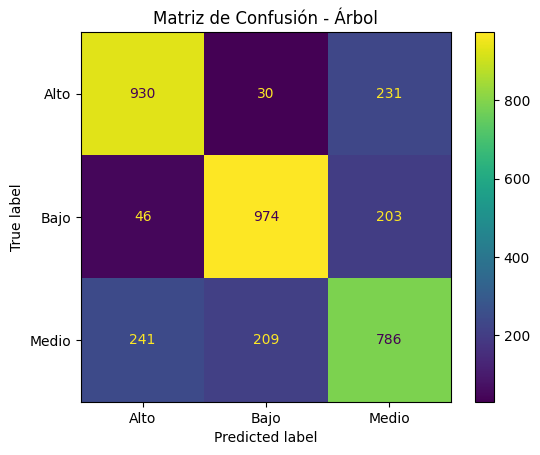

In [19]:
cm = confusion_matrix(y_test, pred_tree, labels=best_tree.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=best_tree.classes_)
disp.plot()
plt.title('Matriz de Confusión - Árbol')
plt.show()

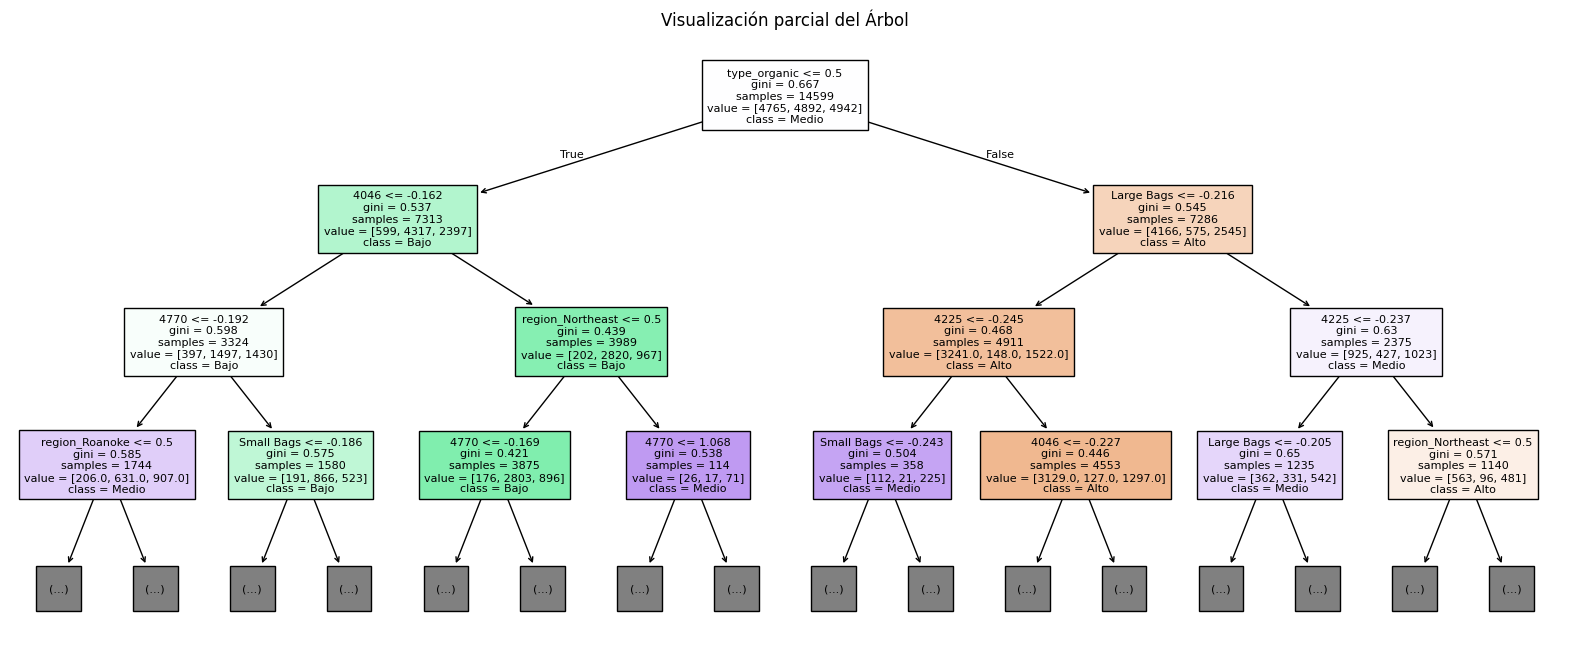

In [20]:
plt.figure(figsize=(20,8))
plot_tree(best_tree, filled=True, feature_names=X.columns, class_names=best_tree.classes_, max_depth=3, fontsize=8)
plt.title('Visualización parcial del Árbol')
plt.show()

# COMPARACIÓN 2

In [21]:
from sklearn.metrics import f1_score


results = pd.DataFrame({
    'Modelo':['KNN','Árbol de Decisión'],
    'Accuracy':[accuracy_score(y_test, pred_knn), accuracy_score(y_test, pred_tree)],
    'F1-Score (Macro)': [f1_score(y_test, pred_knn, average='macro'), f1_score(y_test, pred_tree, average='macro')]
})
results.sort_values('Accuracy', ascending=False)

,Modelo,Accuracy,F1-Score (Macro)
0,KNN,0.786849,0.787599
1,Árbol de Decisión,0.736986,0.737387


# Grafica de comparación

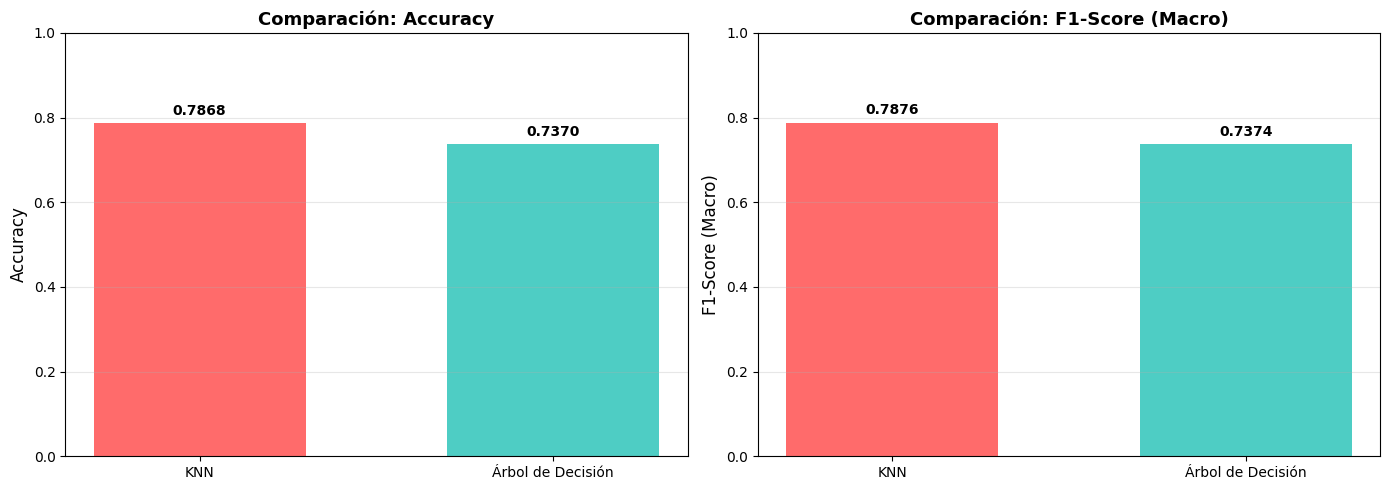

In [22]:
# Gráfica comparativa de modelos de clasificación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Accuracy
axes[0].bar(results['Modelo'], results['Accuracy'], color=['#FF6B6B', '#4ECDC4'], width=0.6)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparación: Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
# Agregar valores en las barras
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Gráfica 2: F1-Score (Macro)
axes[1].bar(results['Modelo'], results['F1-Score (Macro)'], color=['#FF6B6B', '#4ECDC4'], width=0.6)
axes[1].set_ylabel('F1-Score (Macro)', fontsize=12)
axes[1].set_title('Comparación: F1-Score (Macro)', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
# Agregar valores en las barras
for i, v in enumerate(results['F1-Score (Macro)']):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()